In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

file = pd.read_csv("C:/Users/user/OneDrive/Documenti/Astro/astrostatistics_bicocca_2026/solutions/galaxyquasar.csv")
print(file)

              u         g         r         i         z   class        z1  \
0      18.97213  18.53676  18.58280  18.34936  18.29215     QSO  0.522819   
1      19.24592  17.47646  16.47817  16.04472  15.68851  GALAXY  0.122846   
2      19.43536  17.70268  16.91565  16.58327  16.39128  GALAXY  0.000000   
3      19.31626  18.18312  17.39591  16.94549  16.65395  GALAXY  0.147435   
4      19.28828  19.11188  18.88937  18.80013  18.49183     QSO  2.011455   
...         ...       ...       ...       ...       ...     ...       ...   
49995  19.37295  18.12382  17.39886  16.98503  16.70585  GALAXY  0.113016   
49996  18.52021  16.88262  16.03280  15.56884  15.22454  GALAXY  0.085063   
49997  18.62718  17.30876  16.87371  16.62399  16.42296  GALAXY  0.054429   
49998  19.55140  18.27711  17.62101  17.21947  17.03347  GALAXY  0.112571   
49999  18.80772  17.75751  17.40500  17.21650  17.12295  GALAXY  0.043652   

           zerr  
0      0.000155  
1      0.000028  
2      0.000000  
3  

In [2]:
#create array for the (u-g), (g-r), (r-i), and (i-z) colors
#create an array for the class where GALAXY is 0 and QSO is 1


u_g = file['u'] - file['g'] 
g_r = file['g'] - file['r'] 
r_i = file['r'] - file['i'] 
i_z = file['i'] - file['z'] 

classificazione = []
for i in range(len(file)):
    if file['class'][i] == 'GALAXY':
        classificazione.append(0)
    elif file['class'][i] == 'QSO':
        classificazione.append(1)
    else:
        classificazione.append(2)

print(classificazione)
print(u_g, g_r, r_i, i_z)

[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 

In [3]:
#classify the dataset against the target label 
from sklearn.model_selection import train_test_split

stacked = np.array((u_g, g_r, r_i, i_z)).T

X_train, X_val, y_train, y_val = train_test_split(stacked, classificazione, test_size=0.3, random_state=42)


In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_val)

print("Confusion Matrix")
print(confusion_matrix(y_val, y_pred))

print("Classification Report")
print(classification_report(y_val, y_pred))

Confusion Matrix
[[12599   213]
 [  160  2028]]
Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     12812
           1       0.90      0.93      0.92      2188

    accuracy                           0.98     15000
   macro avg       0.95      0.96      0.95     15000
weighted avg       0.98      0.98      0.98     15000



In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Lna = LinearDiscriminantAnalysis()

Lna.fit(X_train, y_train)

y_pred_lna = Lna.predict(X_val)

print("Confusion Matrix")
print(confusion_matrix(y_val, y_pred_lna))

print("Classification Report")
print(classification_report(y_val, y_pred_lna))



Confusion Matrix
[[12689   123]
 [  161  2027]]
Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     12812
           1       0.94      0.93      0.93      2188

    accuracy                           0.98     15000
   macro avg       0.97      0.96      0.96     15000
weighted avg       0.98      0.98      0.98     15000



In [12]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train, y_train)

y_pred_qda = gnb.predict(X_val)

print("Confusion Matrix")
print(confusion_matrix(y_val, y_pred_qda))

print("Classification Report")
print(classification_report(y_val, y_pred_qda))

Confusion Matrix
[[12599   213]
 [  160  2028]]
Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     12812
           1       0.90      0.93      0.92      2188

    accuracy                           0.98     15000
   macro avg       0.95      0.96      0.95     15000
weighted avg       0.98      0.98      0.98     15000



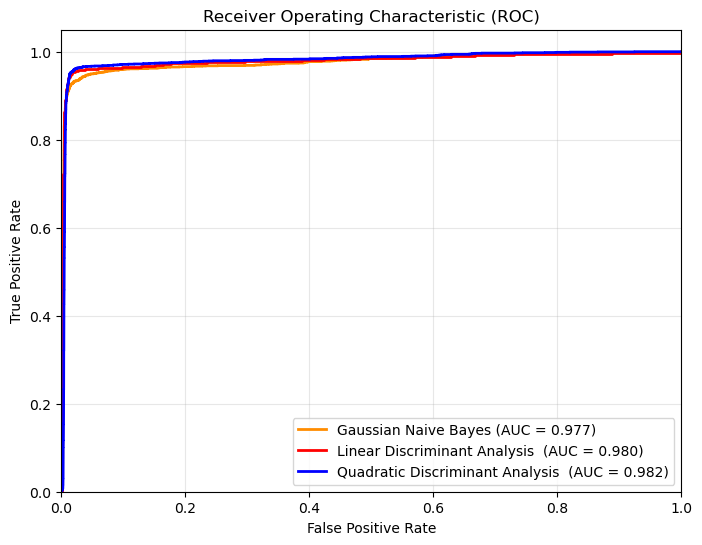

In [15]:
from sklearn.metrics import roc_curve, auc

# 1. Get the predicted probabilities for the positive class
y_prob_gnb = gnb.predict_proba(X_val)[:, 1]
y_prob_lna = Lna.predict_proba(X_val)[:,1]
y_prob_qda = qda.predict_proba(X_val)[:,1]

# 2. Calculate the False Positive Rate (FPR) and True Positive Rate (TPR)
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(y_val, y_prob_gnb)
fpr_lna, tpr_lna, thresholds_lna = roc_curve(y_val, y_prob_lna)
fpr_qda, tpr_qda, thresholds_qda = roc_curve(y_val, y_prob_qda)


# 3. Calculate the Area Under the Curve (AUC)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
roc_auc_lna = auc(fpr_lna, tpr_lna)
roc_auc_qda = auc(fpr_qda, tpr_qda)

# 4. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, color='darkorange', lw=2, label=f'Gaussian Naive Bayes (AUC = {roc_auc_gnb:.3f})')
plt.plot(fpr_lna, tpr_lna, color='red', lw=2, label=f'Linear Discriminant Analysis  (AUC = {roc_auc_lna:.3f})')
plt.plot(fpr_qda, tpr_qda, color='blue', lw=2, label=f'Quadratic Discriminant Analysis  (AUC = {roc_auc_qda:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [22]:
from sklearn.metrics import roc_auc_score

bands = ['u', 'g', 'r', 'i', 'z']

file['u-g'] = file['u'] - file['g']
file['g-r'] = file['g'] - file['r']
file['r-i'] = file['r'] - file['i']
file['i-z'] = file['i'] - file['z']

colors = ['u-g','g-r','r-i','i-z']

print(file[bands].corr().round(2))
print(file[colors].corr().round(2))

y = (file['class'] == 'QSO').astype(int)

gnb = GaussianNB()
# Try single colors first to find the most important feature
for color in colors:
    gnb.fit(np.newaxis(X_train[[color]]), y_train)
    y_prob = gnb.predict_proba(X_val[[color]])[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    print(f"Feature '{color}': AUC = {auc:.4f}")
# Try all colors together
gnb.fit(X_train[colors], y_train)
y_prob_all = gnb.predict_proba(X_val[colors])[:, 1]
auc_all = roc_auc_score(y_val, y_prob_all)
print(f"\nAll colors combined: AUC = {auc_all:.4f}")

      u     g     r     i     z
u  1.00  0.81  0.68  0.62  0.58
g  0.81  1.00  0.97  0.95  0.93
r  0.68  0.97  1.00  0.99  0.98
i  0.62  0.95  0.99  1.00  0.98
z  0.58  0.93  0.98  0.98  1.00
      u-g   g-r   r-i   i-z
u-g  1.00  0.80  0.47  0.36
g-r  0.80  1.00  0.35  0.32
r-i  0.47  0.35  1.00 -0.16
i-z  0.36  0.32 -0.16  1.00


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices